In [1]:
from pyspark.sql import SparkSession
spark = SparkSession.builder \
    .appName("Retail Sales Analytics") \
    .getOrCreate()

In [3]:
import pandas as pd
df = pd.read_excel('./data/Online Retail.xlsx')
df.to_csv('./data/OnlineRetail.csv', index=False)

In [5]:
retail_df = spark.read.csv('./data/OnlineRetail.csv', header=True, inferSchema=True)
retail_df.printSchema()

root
 |-- InvoiceNo: string (nullable = true)
 |-- StockCode: string (nullable = true)
 |-- Description: string (nullable = true)
 |-- Quantity: integer (nullable = true)
 |-- InvoiceDate: timestamp (nullable = true)
 |-- UnitPrice: double (nullable = true)
 |-- CustomerID: double (nullable = true)
 |-- Country: string (nullable = true)



In [7]:
retail_df.summary()

DataFrame[summary: string, InvoiceNo: string, StockCode: string, Description: string, Quantity: string, UnitPrice: string, CustomerID: string, Country: string]

In [8]:
retail_df=retail_df.na.drop(subset=['CustomerID','InvoiceNo','Description'])

In [9]:
retail_df=retail_df.filter(retail_df['Quantity']>0)
retail_df=retail_df.filter(retail_df['UnitPrice']>0)


In [10]:
from pyspark.sql.functions import col
retail_df= retail_df.withColumn('TotalAmount',col('Quantity')*retail_df['UnitPrice'])

In [12]:
top_products=retail_df.groupBy("Description").sum('Quantity').withColumnRenamed("sum(Quantity)", "TotalSold").orderBy(col("TotalSold").desc()).limit(10)
top_products.show()

+--------------------+---------+
|         Description|TotalSold|
+--------------------+---------+
|PAPER CRAFT , LIT...|    80995|
|MEDIUM CERAMIC TO...|    77916|
|WORLD WAR 2 GLIDE...|    54415|
|JUMBO BAG RED RET...|    46181|
|WHITE HANGING HEA...|    36725|
|ASSORTED COLOUR B...|    35362|
|PACK OF 72 RETROS...|    33693|
|      POPCORN HOLDER|    30931|
|  RABBIT NIGHT LIGHT|    27202|
|MINI PAINT SET VI...|    26076|
+--------------------+---------+



In [13]:
top_customers=retail_df.groupBy("CustomerID").sum("TotalAmount").withColumnRenamed("sum(TotalAmount)", "TotalSpent").orderBy(col("TotalSpent").desc()).limit(10)
top_customers.show(10)

+----------+------------------+
|CustomerID|        TotalSpent|
+----------+------------------+
|   14646.0|280206.01999999996|
|   18102.0|259657.29999999996|
|   17450.0|194550.78999999998|
|   16446.0|          168472.5|
|   14911.0|143825.06000000003|
|   12415.0|124914.52999999998|
|   14156.0| 117379.6300000001|
|   17511.0|          91062.38|
|   16029.0|          81024.84|
|   12346.0|           77183.6|
+----------+------------------+



In [14]:
country_sales=retail_df.groupBy("Country").sum("TotalAmount").orderBy(col("Sum(TotalAmount)").desc())
country_sales.show()

+---------------+------------------+
|        Country|  sum(TotalAmount)|
+---------------+------------------+
| United Kingdom| 7308391.554000131|
|    Netherlands|         285446.34|
|           EIRE| 265545.9000000003|
|        Germany|228867.13999999993|
|         France| 209024.0500000001|
|      Australia|138521.30999999997|
|          Spain|          61577.11|
|    Switzerland| 56443.94999999997|
|        Belgium|41196.340000000004|
|         Sweden| 38378.33000000001|
|          Japan|          37416.37|
|         Norway|          36165.44|
|       Portugal|          33439.89|
|        Finland|          22546.08|
|      Singapore|          21279.29|
|Channel Islands|20450.440000000006|
|        Denmark|18955.339999999997|
|          Italy|          17483.24|
|         Cyprus|13590.379999999997|
|        Austria|          10198.68|
+---------------+------------------+
only showing top 20 rows



In [16]:
returns_df = spark.read.csv('./data/OnlineRetail.csv', header=True, inferSchema=True)
returns_df = returns_df.filter(returns_df["InvoiceNo"].startswith("C"))
returns_df.groupBy("Description").count().orderBy("count", ascending=False).show()

+--------------------+-----+
|         Description|count|
+--------------------+-----+
|              Manual|  244|
|REGENCY CAKESTAND...|  181|
|             POSTAGE|  126|
|JAM MAKING SET WI...|   87|
|            Discount|   77|
|SET OF 3 CAKE TIN...|   74|
|             SAMPLES|   61|
|STRAWBERRY CERAMI...|   55|
|ROSES REGENCY TEA...|   54|
|RECIPE BOX PANTRY...|   47|
|WOOD 2 DRAWER CAB...|   45|
|JUMBO BAG RED RET...|   44|
|LUNCH BAG RED RET...|   44|
|RED RETROSPOT CAK...|   42|
|GREEN REGENCY TEA...|   42|
|WHITE HANGING HEA...|   42|
|SMALL GLASS HEART...|   40|
|SET OF 3 REGENCY ...|   37|
|      POPCORN HOLDER|   36|
|SET OF TEA COFFEE...|   35|
+--------------------+-----+
only showing top 20 rows



<Axes: xlabel='Description'>

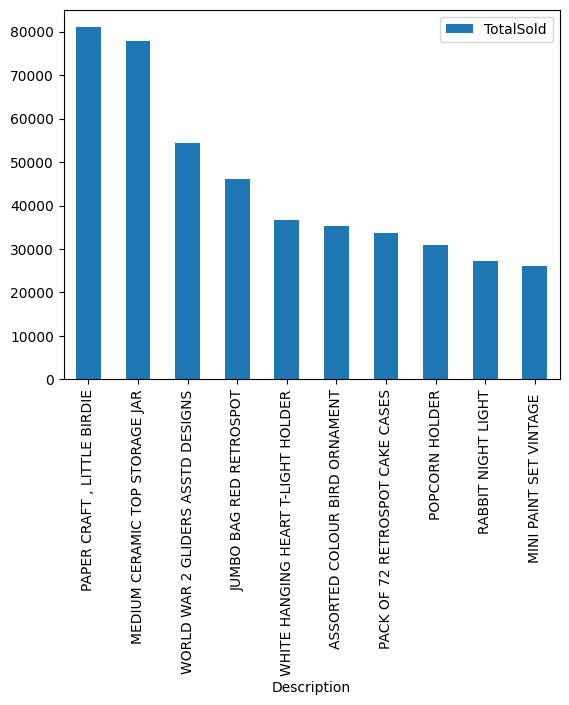

In [17]:
top_products_pd = top_products.toPandas()
top_products_pd.plot(kind="bar", x="Description", y="TotalSold")

In [23]:
top_customers.coalesce(1).write.csv("./output/top_customers", header=True, mode="overwrite")

Py4JJavaError: An error occurred while calling o234.csv.
: java.lang.UnsatisfiedLinkError: 'boolean org.apache.hadoop.io.nativeio.NativeIO$Windows.access0(java.lang.String, int)'
	at org.apache.hadoop.io.nativeio.NativeIO$Windows.access0(Native Method)
	at org.apache.hadoop.io.nativeio.NativeIO$Windows.access(NativeIO.java:793)
	at org.apache.hadoop.fs.FileUtil.canRead(FileUtil.java:1249)
	at org.apache.hadoop.fs.FileUtil.list(FileUtil.java:1454)
	at org.apache.hadoop.fs.RawLocalFileSystem.listStatus(RawLocalFileSystem.java:601)
	at org.apache.hadoop.fs.FileSystem.listStatus(FileSystem.java:1972)
	at org.apache.hadoop.fs.FileSystem.listStatus(FileSystem.java:2014)
	at org.apache.hadoop.fs.ChecksumFileSystem.listStatus(ChecksumFileSystem.java:761)
	at org.apache.hadoop.fs.FileSystem.listStatus(FileSystem.java:1972)
	at org.apache.hadoop.fs.FileSystem.listStatus(FileSystem.java:2014)
	at org.apache.hadoop.mapreduce.lib.output.FileOutputCommitter.getAllCommittedTaskPaths(FileOu

In [22]:
top_customers.write.csv("./output/top_customers", header=True)

Py4JJavaError: An error occurred while calling o229.csv.
: java.lang.UnsatisfiedLinkError: 'boolean org.apache.hadoop.io.nativeio.NativeIO$Windows.access0(java.lang.String, int)'
	at org.apache.hadoop.io.nativeio.NativeIO$Windows.access0(Native Method)
	at org.apache.hadoop.io.nativeio.NativeIO$Windows.access(NativeIO.java:793)
	at org.apache.hadoop.fs.FileUtil.canRead(FileUtil.java:1249)
	at org.apache.hadoop.fs.FileUtil.list(FileUtil.java:1454)
	at org.apache.hadoop.fs.RawLocalFileSystem.listStatus(RawLocalFileSystem.java:601)
	at org.apache.hadoop.fs.FileSystem.listStatus(FileSystem.java:1972)
	at org.apache.hadoop.fs.FileSystem.listStatus(FileSystem.java:2014)
	at org.apache.hadoop.fs.ChecksumFileSystem.listStatus(ChecksumFileSystem.java:761)
	at org.apache.hadoop.fs.FileSystem.listStatus(FileSystem.java:1972)
	at org.apache.hadoop.fs.FileSystem.listStatus(FileSystem.java:2014)
	at org.apache.hadoop.mapreduce.lib.output.FileOutputCommitter.getAllCommittedTaskPaths(FileOu